## Read files and combine them into a dataframe

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

In [32]:
all_files = glob.glob("/Users/jingying/Documents/IDX Exchange/py/csv/*CRMLSSold*.csv")
all_files

['/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202404_filled.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202409.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202408.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202501_filled.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202401_filled.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202406_filled.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202509.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202508.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202403_filled.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202503.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202502.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202405_filled.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202505.csv',
 '/Users/jingying/Documents/IDX Exchange/py/csv/

In [34]:
len(all_files)

28

In [36]:
from pathlib import Path
import re

folder = Path("/Users/jingying/Documents/IDX Exchange/py/csv")

files = []

for file in folder.glob("CRMLSSold*.csv"):
    if re.fullmatch(r"CRMLSSold\d{6}(?:_filled)?.csv", file.name):
        files.append(file)
        
files.sort(key=lambda file: file.name[9:15])

files

[PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202401_filled.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202402.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202403_filled.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202404_filled.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202405_filled.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202406_filled.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202407_filled.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202408.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202409.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202410.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold202411.csv'),
 PosixPath('/Users/jingying/Documents/IDX Exchange/py/csv/CRMLSSold

In [38]:
df = []

for file in files:
    monthly_data = pd.read_csv(file, low_memory=False)
    monthly_data["Date"] = file.name[9:15]
    df.append(monthly_data)
combined_sold_data = pd.concat(df, ignore_index=True)

combined_sold_data

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,Date,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,6472.0,NaN,NaN,True,True,202401,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,52320.0,NaN,False,False,202401,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,217364.0,NaN,False,False,202401,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,217800.0,NaN,False,False,202401,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,0.0,108883.0,NaN,False,False,202401,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615702,NaN,True,NaN,NaN,NaN,200000.0,1014741959,dtownsendrealestate@gmail.com,2026-04-20,85000.0,...,0.0,910839.6,NaN,NaN,NaN,202604,SierraNorthValley,SierraNorthValley,CRMLS,CRMLS_CRM
615703,NaN,True,NaN,NaN,NaN,97500.0,1002540286,scott@westcoe.com,2026-04-03,85000.0,...,0.0,522720.0,NaN,NaN,NaN,202604,SouthwestRiversideCounty,InlandValleys,CRMLS,CRMLS_CRM
615704,NaN,True,NaN,NaN,NaN,15999.0,482785043,mr.khatibi@yahoo.com,2026-04-28,19000.0,...,0.0,20009.0,NaN,NaN,NaN,202604,Mrmls,Southland,CRMLS,CRMLS_CRM
615705,NaN,True,NaN,NaN,NaN,6000000.0,446619807,jeffnyal@gmail.com,2026-04-15,4500000.0,...,NaN,122839.0,NaN,NaN,NaN,202604,OrangeCounty,HighDesert,CRMLS,CRMLS_CRM


In [39]:
combined_sold_data.shape

(615707, 85)

In [42]:
combined_sold_data.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

In [44]:
columns_by_file = {}  # Store the column names from each CSV file.

for file in files:  # Check every monthly Sold file.
    columns = pd.read_csv(file, nrows=0).columns.tolist()  # Read only the header row.
    columns_by_file[file.name] = columns  # Save the column names under the filename.

reference_name = files[0].name  # Use the first file as the reference.
reference_columns = columns_by_file[reference_name]  # Get its column names.
reference_set = set(reference_columns)  # Use a set to compare column names.

print(f"Reference file: {reference_name}")  # Show which file is the reference.
print(f"Reference column count: {len(reference_columns)}")  # Show its column count.

for name, columns in columns_by_file.items():  # Compare each file with the reference.
    extra = sorted(set(columns) - reference_set)  # Find columns absent from the reference.
    missing = sorted(reference_set - set(columns))  # Find reference columns absent from this file.

    if extra or missing:  # Print only files whose column names differ.
        print(f"\n{name}: {len(columns)} columns")
        print(f"  Extra:   {extra}")
        print(f"  Missing: {missing}")

Reference file: CRMLSSold202401_filled.csv
Reference column count: 80

CRMLSSold202402.csv: 78 columns
  Extra:   []
  Missing: ['latfilled', 'lonfilled']

CRMLSSold202405_filled.csv: 80 columns
  Extra:   ['BuyerAgentAOR', 'ListAgentAOR']
  Missing: ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType']

CRMLSSold202406_filled.csv: 80 columns
  Extra:   ['BuyerAgentAOR', 'ListAgentAOR']
  Missing: ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType']

CRMLSSold202407_filled.csv: 80 columns
  Extra:   ['BuyerAgentAOR', 'ListAgentAOR']
  Missing: ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType']

CRMLSSold202408.csv: 78 columns
  Extra:   ['BuyerAgentAOR', 'ListAgentAOR']
  Missing: ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'latfilled', 'lonfilled']

CRMLSSold202409.csv: 78 columns
  Extra:   ['BuyerAgentAOR', 'ListAgentAOR']
  Missing: ['BuyerAgencyCompensation', 'BuyerAgencyCompensationType', 'latfilled', 'lonfilled']

CRMLSSold202410.csv: 78 columns

## Restrict analysis to Residential \& SingleFamilyResidence 

In [46]:
combined_sold_data["PropertyType"].value_counts()

PropertyType
Residential            414054
ResidentialLease       140960
Land                    20038
ManufacturedInPark      16706
ResidentialIncome       16476
CommercialSale           3843
CommercialLease          3216
BusinessOpportunity       414
Name: count, dtype: int64

In [48]:
combined_sold_data["PropertySubType"].value_counts()

PropertySubType
SingleFamilyResidence    376086
Condominium              107040
Townhouse                 35545
Apartment                 14185
Duplex                    11759
ManufacturedOnLand         6232
Quadruplex                 3667
Triplex                    3666
StockCooperative           2076
MixedUse                   1894
Office                     1656
Retail                     1102
Industrial                  705
Cabin                       525
Studio                      449
Business                    411
RoomingHouse                310
Warehouse                   308
SpecialPurpose              155
MultiFamily                 144
BoatSlip                    117
Agriculture                  87
MobileHome                   83
OwnYourOwn                   79
Loft                         74
UnimprovedLand               71
WaterPositionWithLand        70
ManufacturedHome             58
Timeshare                    21
HotelMotel                   18
CoOwnership             

In [50]:
res_sfr_combined_sold_data = combined_sold_data[(combined_sold_data["PropertyType"]=="Residential") & (combined_sold_data["PropertySubType"]=="SingleFamilyResidence")]

res_sfr_combined_sold_data.shape

(309735, 85)

In [52]:
cols = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeAcres", "LotSizeArea", "LotSizeSquareFeet"]
missing_value_count = res_sfr_combined_sold_data[cols].isna().sum()
missing_value_count

ClosePrice                  2
LivingArea                166
BedroomsTotal               0
BathroomsTotalInteger      50
LotSizeAcres             5354
LotSizeArea              5303
LotSizeSquareFeet        5327
dtype: int64

In [105]:
missing_value_ratio = missing_value_count/res_sfr_combined_sold_data.shape[0]
missing_value_ratio

ClosePrice               0.000006
LivingArea               0.000536
BedroomsTotal            0.000000
BathroomsTotalInteger    0.000161
LotSizeAcres             0.017286
LotSizeArea              0.017121
LotSizeSquareFeet        0.017199
dtype: float64

`LotSizeSquareFeet` has slightly fewer missing values than `LotSizeAcres` in the filtered data (1.72% versus 1.73%)

In [54]:
res_sfr_combined_sold_data[cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 309735 entries, 5 to 615680
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ClosePrice             309733 non-null  float64
 1   LivingArea             309569 non-null  float64
 2   BedroomsTotal          309735 non-null  float64
 3   BathroomsTotalInteger  309685 non-null  float64
 4   LotSizeAcres           304381 non-null  float64
 5   LotSizeArea            304432 non-null  float64
 6   LotSizeSquareFeet      304408 non-null  float64
dtypes: float64(7)
memory usage: 18.9 MB


In [56]:
res_sfr_combined_sold_data[cols].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeAcres,LotSizeArea,LotSizeSquareFeet
count,3.097330e+05,309569.000000,309735.000000,309685.000000,3.043810e+05,3.044320e+05,3.044080e+05
mean,1.297553e+06,2033.883475,3.480905,2.616581,3.811137e+01,2.094266e+04,2.666652e+05
std,5.643293e+06,1058.296353,0.961522,1.199603,1.421163e+04,7.049530e+05,1.460283e+07
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.250000e+05,1376.000000,3.000000,2.000000,1.300000e-01,5.466000e+03,5.663000e+03
50%,8.940000e+05,1804.000000,3.000000,2.000000,1.663000e-01,7.100000e+03,7.245000e+03
75%,1.430000e+06,2421.000000,4.000000,3.000000,2.376000e-01,9.906000e+03,1.035000e+04
max,9.895000e+08,123764.000000,45.000000,175.000000,7.810698e+06,2.178000e+08,2.087221e+09


| Variable | Explanation |
|---|---|
| `LotSizeSquareFeet` | Main lot-size variable for plots and modeling |
| `LotSizeAcres` | Alternative unit, useful for checking the square-foot values |
| `LotSizeArea` | Use only after checking `LotSizeUnits`, since its unit can vary |
| `LotSizeDimensions` | Descriptive text, unsuitable as a direct numeric size |

For a quick consistency check, one acre should equal 43,560 square feet:

In [132]:
lot_check = res_sfr_combined_sold_data[["LotSizeAcres", "LotSizeSquareFeet"]].dropna()
lot_check = lot_check[(lot_check["LotSizeAcres"] > 0) & (lot_check["LotSizeSquareFeet"] > 0)].copy()

lot_check["sqft_from_acres"] = lot_check["LotSizeAcres"] * 43560 
lot_check["ratio"] = lot_check["LotSizeSquareFeet"] / lot_check["sqft_from_acres"]

lot_check["ratio"].describe(percentiles=[0.01, 0.50, 0.99]) 

count    303929.000000
mean          0.999981
std           0.007681
min           0.213039
1%            0.999447
50%           1.000000
99%           1.000577
max           4.683196
Name: ratio, dtype: float64

Among the 303,929 records with positive values for both lot-size fields, `LotSizeSquareFeet` closely matches `LotSizeAcres` after conversion to square feet. The median ratio is 1.000, and the 1st to 99th percentile ranges from 0.999447 to 1.000577. A few records show substantial discrepancies, with ratios as low as 0.213 and as high as 4.683. I will use `LotSizeSquareFeet` for the exploratory plots and review the discrepant records before deciding how to handle them in the model.

In [147]:
res_sfr_combined_sold_data["BedroomsTotal"].value_counts()

BedroomsTotal
3.0     131450
4.0     102859
2.0      35058
5.0      31373
6.0       5324
1.0       1993
7.0       1036
8.0        293
0.0        176
9.0         82
10.0        43
11.0        14
12.0        13
13.0         6
15.0         4
14.0         3
16.0         2
34.0         1
31.0         1
45.0         1
17.0         1
19.0         1
22.0         1
Name: count, dtype: int64

In [149]:
res_sfr_combined_sold_data["BathroomsTotalInteger"].value_counts()

BathroomsTotalInteger
2.0      134053
3.0      103101
1.0       29178
4.0       25241
5.0       10942
6.0        4281
7.0        1518
8.0         621
9.0         301
10.0        138
0.0         132
11.0         68
12.0         42
13.0         25
14.0         12
15.0          6
16.0          5
18.0          4
20.0          3
17.0          2
21.0          2
27.0          2
45.0          1
35.0          1
31.0          1
153.0         1
25.0          1
22.0          1
175.0         1
23.0          1
Name: count, dtype: int64

In [204]:
bed_bath_check = res_sfr_combined_sold_data[["BedroomsTotal", "BathroomsTotalInteger"]].dropna()
bed_bath_check = bed_bath_check[(bed_bath_check["BedroomsTotal"] > 0) & (bed_bath_check["BathroomsTotalInteger"] > 0)].copy()

bed_bath_check["bed_bath_ratio"] = bed_bath_check["BedroomsTotal"] / bed_bath_check["BathroomsTotalInteger"]

bed_bath_check["bed_bath_ratio"].describe(percentiles=[0.01, 0.50, 0.99]) 

count    309476.000000
mean          1.460573
std           0.477028
min           0.011429
1%            0.666667
50%           1.500000
99%           3.000000
max           7.500000
Name: bed_bath_ratio, dtype: float64

| Variable | Type | Number of NaNs | Percentage of NaNs | Explanation | 
|---|---|---|---|---|
| `ClosePrice` | float64 | 2 | 0.0006% | The amount of money paid by the purchaser to the seller for the property under the agreement |
| `LivingArea` | float64 | 166 | 0.0536% | The total livable area within the structure |
| `BedroomsTotal` | int64 | 0 | 0 | The total number of bedrooms in the dwelling |
| `BathroomsTotalInteger` | int64 | 50 | 0.0161% | The simple sum of the number of bathrooms |
| `LotSizeSquareFeet` | float64 | 5327 | 1.7199% | The total square footage of the lot |

## Check the outliers

In [58]:
#median absolute deviation method
def median_abs_dev(df, features, n=3):
    for i in features:
        feature = df[i]
        median = feature.quantile(0.5)
        abs_value = (feature - median).abs()
        mad = abs_value.quantile(0.5)
        lower_bound = median - n*mad
        upper_bound = median + n*mad
        outliers = feature[(feature < lower_bound) | (feature > upper_bound)]
        if not outliers.empty:
            print(f"{i} has outliers:\n{outliers}.\n")
        else:
            print(f"{i} has no outliers.")

median_abs_dev(res_sfr_combined_sold_data[cols], cols, n=3)

ClosePrice has outliers:
28         2100000.0
29         1950000.0
31         2340000.0
38         2150000.0
40         2000000.0
             ...    
615601     6925000.0
615611    17830000.0
615635     7400000.0
615637     5860000.0
615658     2425888.0
Name: ClosePrice, Length: 43220, dtype: float64.

LivingArea has outliers:
28         3736.0
41         3383.0
50         3799.0
55         5410.0
56         6424.0
           ...   
615601     8736.0
615611     9648.0
615635    10400.0
615637     4046.0
615658     4800.0
Name: LivingArea, Length: 27620, dtype: float64.

BedroomsTotal has outliers:
531       9.0
1440      7.0
5090      8.0
5252      7.0
5880      7.0
         ... 
614878    7.0
615103    7.0
615313    8.0
615423    7.0
615598    7.0
Name: BedroomsTotal, Length: 1502, dtype: float64.

BathroomsTotalInteger has outliers:
55         8.0
56         6.0
74         6.0
75         6.0
138        7.0
          ... 
615547     6.0
615598     9.0
615601     9.0
615611     9.0
6

The median absolute deviation method is not approporiate in this case, since the distribution is right-skewed, this method will detect more outliers.

In [60]:
#3sigma rule
def find_extreme_3sigma(df, features, n=3):
    for i in features:
        feature = df[i]
        mean = feature.mean()
        sd = feature.std()
        lower_bound = mean - n*sd
        upper_bound = mean + n*sd
        outliers = feature[(feature < lower_bound) | (feature > upper_bound)]
        if not outliers.empty:
            print(f"{i} has outliers:\n{outliers}.\n")
        else:
            print(f"{i} has no outliers.")

find_extreme_3sigma(res_sfr_combined_sold_data[cols], cols, n=3)

ClosePrice has outliers:
1163       18500000.0
6468       31000000.0
15091      20000000.0
16442      22000000.0
16804      18500000.0
             ...     
611896    796000000.0
614332     19750000.0
614369     25500000.0
615407     31750000.0
615471     22500000.0
Name: ClosePrice, Length: 250, dtype: float64.

LivingArea has outliers:
55         5410.0
56         6424.0
74         7500.0
75         5218.0
138        6181.0
           ...   
615591     5794.0
615598    10369.0
615601     8736.0
615611     9648.0
615635    10400.0
Name: LivingArea, Length: 4272, dtype: float64.

BedroomsTotal has outliers:
531       9.0
1440      7.0
5090      8.0
5252      7.0
5880      7.0
         ... 
614878    7.0
615103    7.0
615313    8.0
615423    7.0
615598    7.0
Name: BedroomsTotal, Length: 1678, dtype: float64.

BathroomsTotalInteger has outliers:
55         8.0
138        7.0
247        7.0
498        8.0
523        8.0
          ... 
615471     7.0
615598     9.0
615601     9.0
615611  

In [62]:
# (Q1 - 1.5 × IQR, Q3 + 1.5 × IQR) method
def find_outliers_IQR(df, features):
    for i in features:
        feature = df[i]
        Q1 = feature.quantile(0.025)
        Q3 = feature.quantile(0.975)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        outliers = feature[(feature < lower_bound) | (feature > upper_bound)]
        if not outliers.empty:
            print(f"{i} has outliers:\n{outliers}.\n")
        else:
            print(f"{i} has no outliers.")

find_outliers_IQR(res_sfr_combined_sold_data[cols], cols)

ClosePrice has outliers:
531       13850000.0
1163      18500000.0
4164      11700000.0
6055      13830000.0
6091      10950000.0
             ...    
615407    31750000.0
615471    22500000.0
615557    10400000.0
615598    17000000.0
615611    17830000.0
Name: ClosePrice, Length: 1017, dtype: float64.

LivingArea has outliers:
531       14543.0
7673      12156.0
15516     10934.0
16442     10011.0
16632     10000.0
           ...   
615297    10050.0
615429    11000.0
615471    11000.0
615598    10369.0
615635    10400.0
Name: LivingArea, Length: 327, dtype: float64.

BedroomsTotal has outliers:
45677     10.0
55177     12.0
59225     14.0
61040     11.0
68377     11.0
          ... 
566872    10.0
585821    10.0
589658    10.0
593632    11.0
595657    10.0
Name: BedroomsTotal, Length: 91, dtype: float64.

BathroomsTotalInteger has outliers:
531        13.0
4164       13.0
16804      13.0
32327     175.0
37369      14.0
          ...  
590487     12.0
596845     14.0
599471     13.0
6

## Boxplots

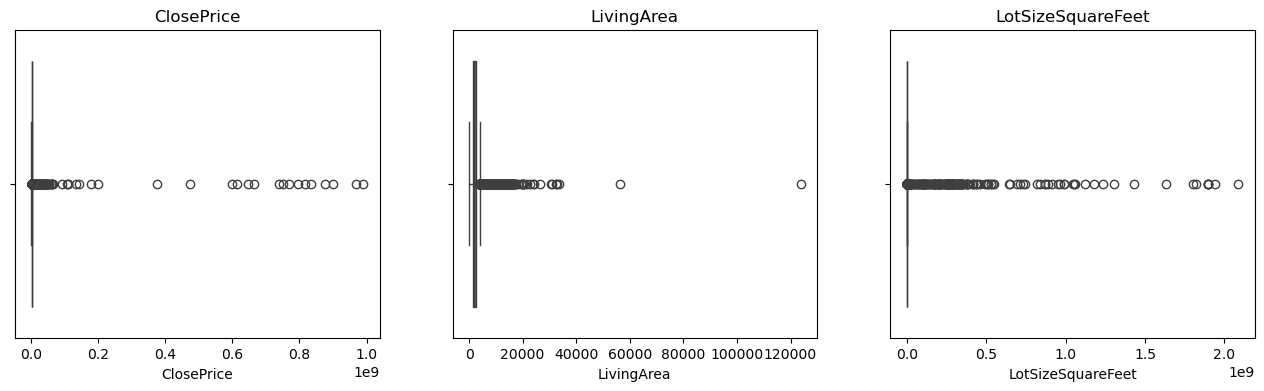

In [152]:
continuous_cols = ["ClosePrice", "LivingArea", "LotSizeSquareFeet"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, continuous_cols):
    values = res_sfr_combined_sold_data[col].dropna()
    
    sns.boxplot(x=values, ax=ax)
    ax.set_title(col)

plt.show()

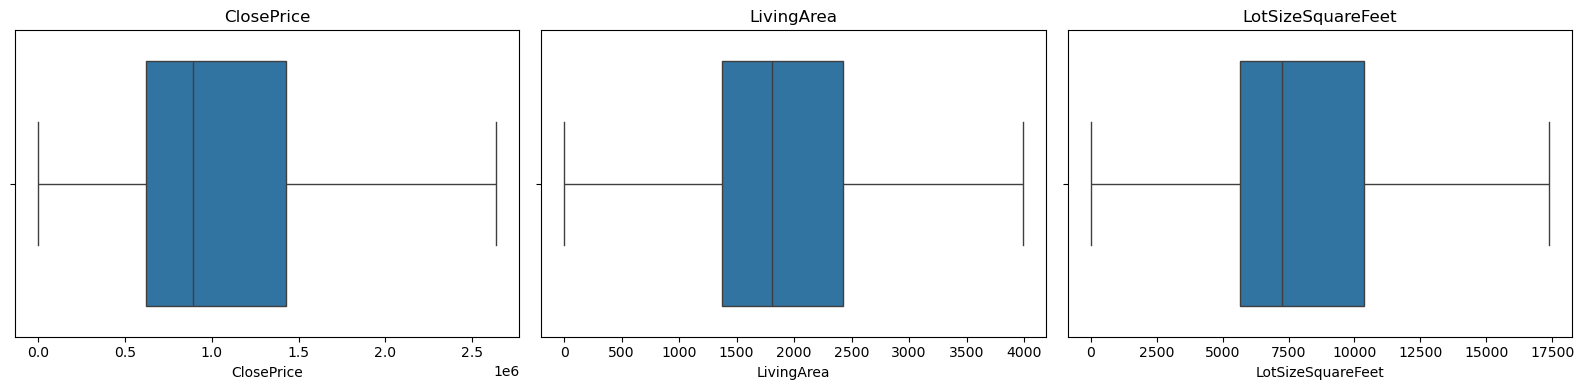

In [156]:
continuous_cols = ["ClosePrice", "LivingArea", "LotSizeSquareFeet"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, continuous_cols):
    # Convert values to numbers and exclude missing values.
    values = pd.to_numeric(res_sfr_combined_sold_data[col], errors="coerce").dropna()

    sns.boxplot(x=values, ax=ax, showfliers=False) #without ouliers
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Histograms

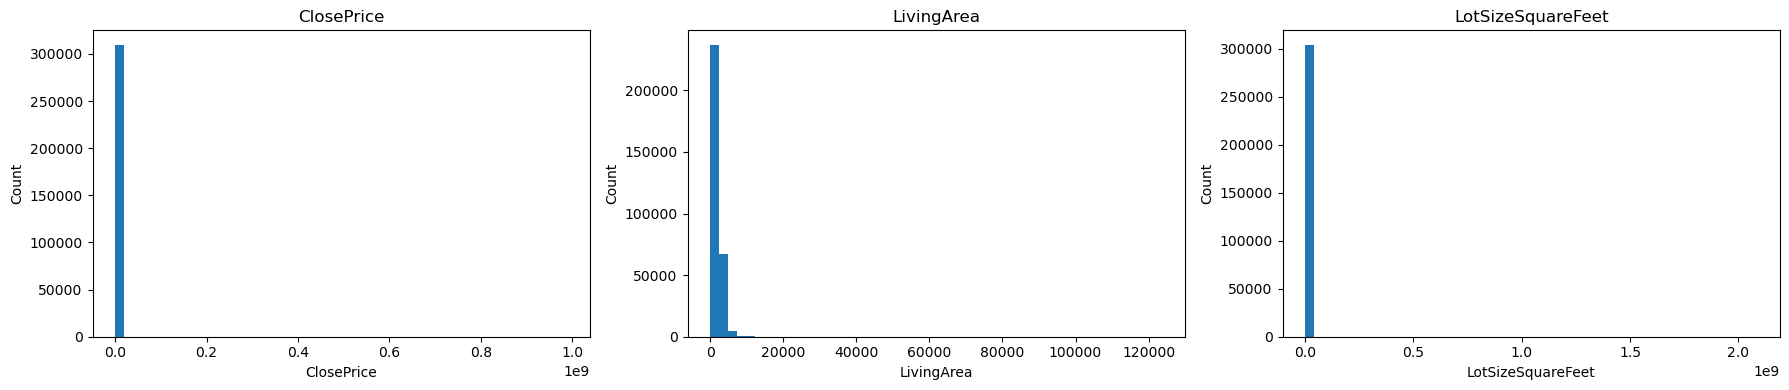

In [172]:
continuous_cols = ["ClosePrice", "LivingArea", "LotSizeSquareFeet"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, continuous_cols):
    values = pd.to_numeric(res_sfr_combined_sold_data[col], errors="coerce").dropna()

    ax.hist(values, bins=50)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

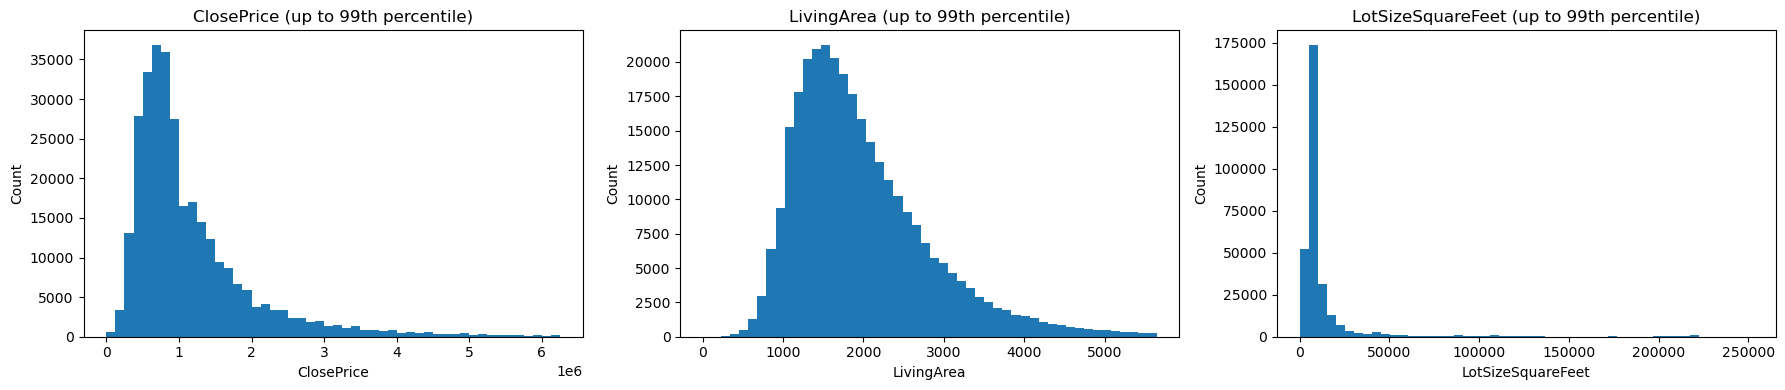

In [170]:
continuous_cols = ["ClosePrice", "LivingArea", "LotSizeSquareFeet"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, continuous_cols):
    values = pd.to_numeric(res_sfr_combined_sold_data[col], errors="coerce").dropna()

    # Limit the displayed range without changing the original data.
    values = values[values > 0]
    upper_limit = values.quantile(0.99)
    values = values[values <= upper_limit]

    ax.hist(values, bins=50)
    ax.set_title(f"{col} (up to 99th percentile)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

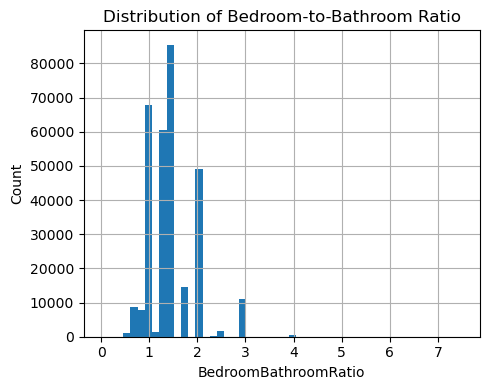

In [222]:
ax = bed_bath_check["bed_bath_ratio"].hist(bins=50, figsize=(5, 4))
ax.set_title("Distribution of Bedroom-to-Bathroom Ratio")
ax.set_xlabel("BedroomBathroomRatio")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Countplots

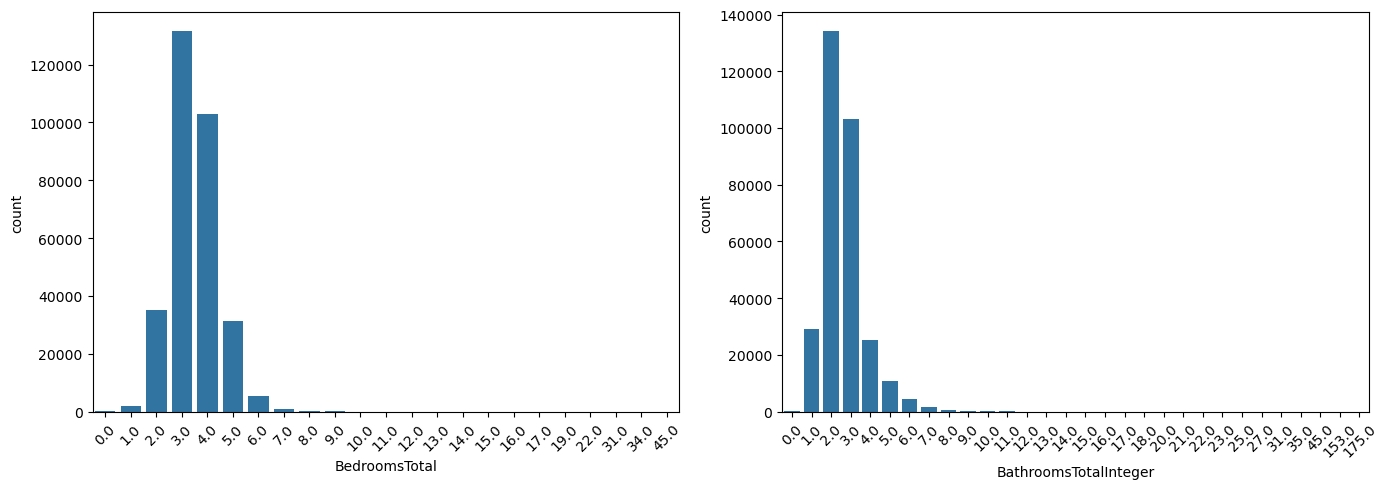

In [197]:
count_cols = ["BedroomsTotal", "BathroomsTotalInteger"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, count_cols):
    values = pd.to_numeric(res_sfr_combined_sold_data[col], errors="coerce").dropna()

    sns.countplot(x=values, order=sorted(values.unique()), ax=ax)
    #ax.set_title(col)
    #ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

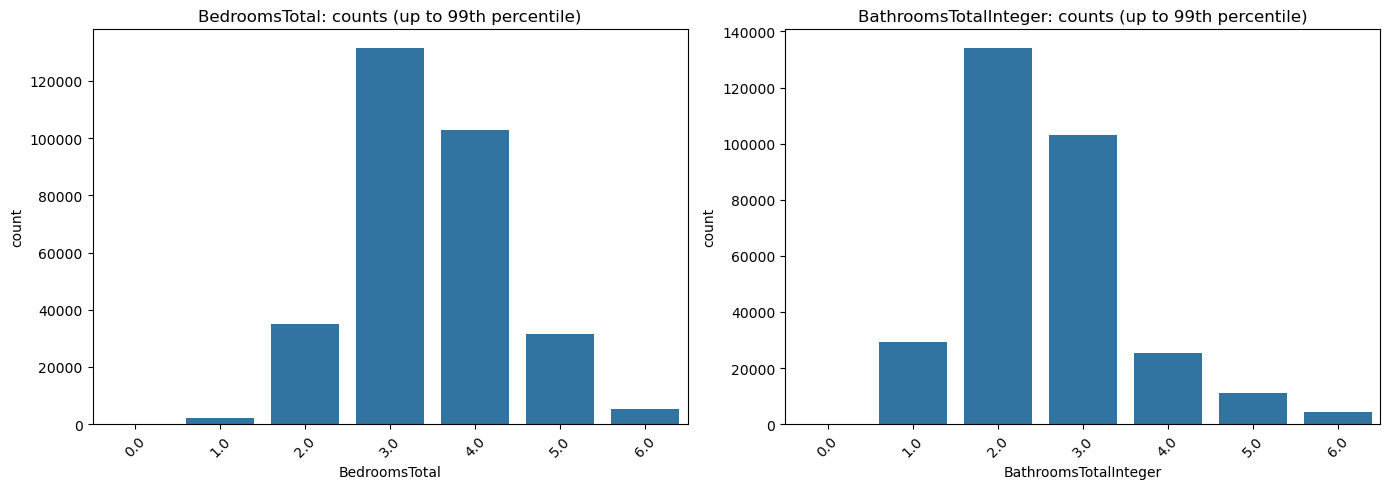

In [192]:
count_cols = ["BedroomsTotal", "BathroomsTotalInteger"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, count_cols):
    values = pd.to_numeric(res_sfr_combined_sold_data[col], errors="coerce").dropna()

    # Keep values from zero through the 99th percentile for this plot.
    plot_values = values[values.between(0, values.quantile(0.99), inclusive="both")]

    # Draw one bar for each observed count.
    sns.countplot(x=plot_values, order=sorted(plot_values.unique()), ax=ax)
    ax.set_title(f"{col}: counts (up to 99th percentile)")
    #ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [323]:
cols = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
correlation_value = res_sfr_combined_sold_data[cols].corr()
correlation_value

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
ClosePrice,1.000000,0.152436,0.084393,0.131054,0.000829
LivingArea,0.152436,1.000000,0.639166,0.776103,0.007239
BedroomsTotal,0.084393,0.639166,1.000000,0.615641,0.004274
BathroomsTotalInteger,0.131054,0.776103,0.615641,1.000000,0.005235
LotSizeSquareFeet,0.000829,0.007239,0.004274,0.005235,1.000000


<Axes: >

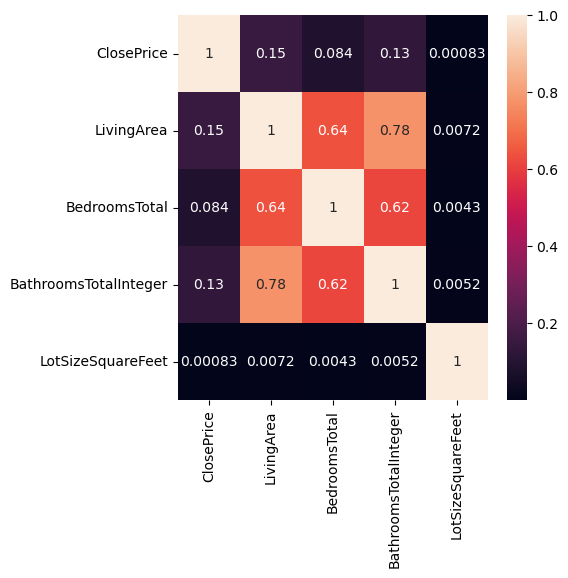

In [327]:
plt.figure(figsize=(5,5))
sns.heatmap(correlation_value, annot=True)

## Segementaion of Close Price: low, medium, high, extremely high

In [396]:
seg_data = res_sfr_combined_sold_data.dropna(subset=["ClosePrice"]).copy()

q50, q90, q99 = seg_data["ClosePrice"].quantile([0.50, 0.90, 0.99])

print(f"50th quantile: ${q50:,.0f}")
print(f"90th quantile: ${q90:,.0f}")
print(f"99th quantile: ${q99:,.0f}")

50th quantile: $894,000
90th quantile: $2,300,000
99th quantile: $6,250,000


In [398]:
ClosePriceLabels = ["Low", "Medium", "High", "Extremely high"]

seg_data["close_price_segment"] = pd.cut(seg_data["ClosePrice"], bins=[0, q50, q90, q99, np.inf], labels=ClosePriceLabels, include_lowest=True)
seg_data["close_price_segment"]

5            Low
9            Low
28        Medium
29        Medium
31          High
           ...  
615673       Low
615674       Low
615675       Low
615677       Low
615680    Medium
Name: close_price_segment, Length: 309733, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Extremely high']

In [400]:
seg_data["close_price_segment"].value_counts()

close_price_segment
Low               154889
Medium            124018
High               27755
Extremely high      3071
Name: count, dtype: int64

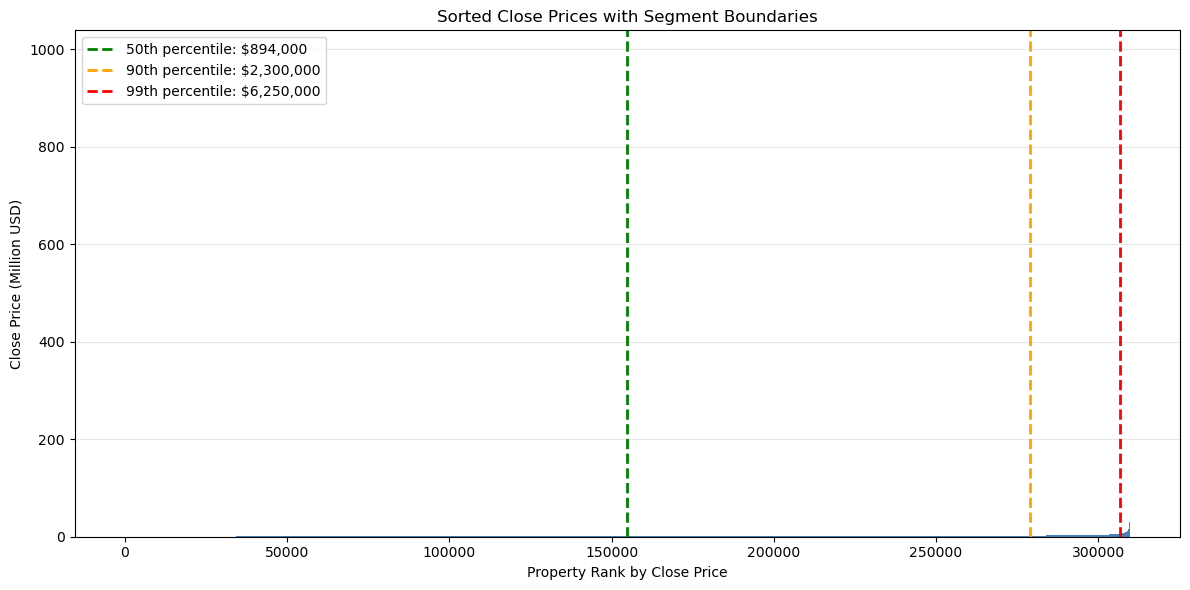

In [402]:
sorted_data = seg_data[["ClosePrice", "close_price_segment"]].copy()
sorted_data["ClosePrice"] = pd.to_numeric(sorted_data["ClosePrice"], errors="coerce")
sorted_data = sorted_data.sort_values("ClosePrice").reset_index(drop=True)

rank = np.arange(1, len(sorted_data) + 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(rank, height=sorted_data["ClosePrice"] / 1_000_000, color="steelblue", width=1, linewidth=0)

cutoffs = [q50, q90, q99]
labels = ["50th percentile", "90th percentile", "99th percentile"]
colors = ["green", "orange", "red"]

for cutoff, label, color in zip(cutoffs, labels, colors):
    boundary_rank = (sorted_data["ClosePrice"] <= cutoff).sum() + 0.5
    ax.axvline(boundary_rank, color=color, linestyle="--", linewidth=2, label=f"{label}: ${cutoff:,.0f}")

ax.set_title("Sorted Close Prices with Segment Boundaries")
ax.set_xlabel("Property Rank by Close Price")
ax.set_ylabel("Close Price (Million USD)")
ax.ticklabel_format(axis="y", style="plain")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

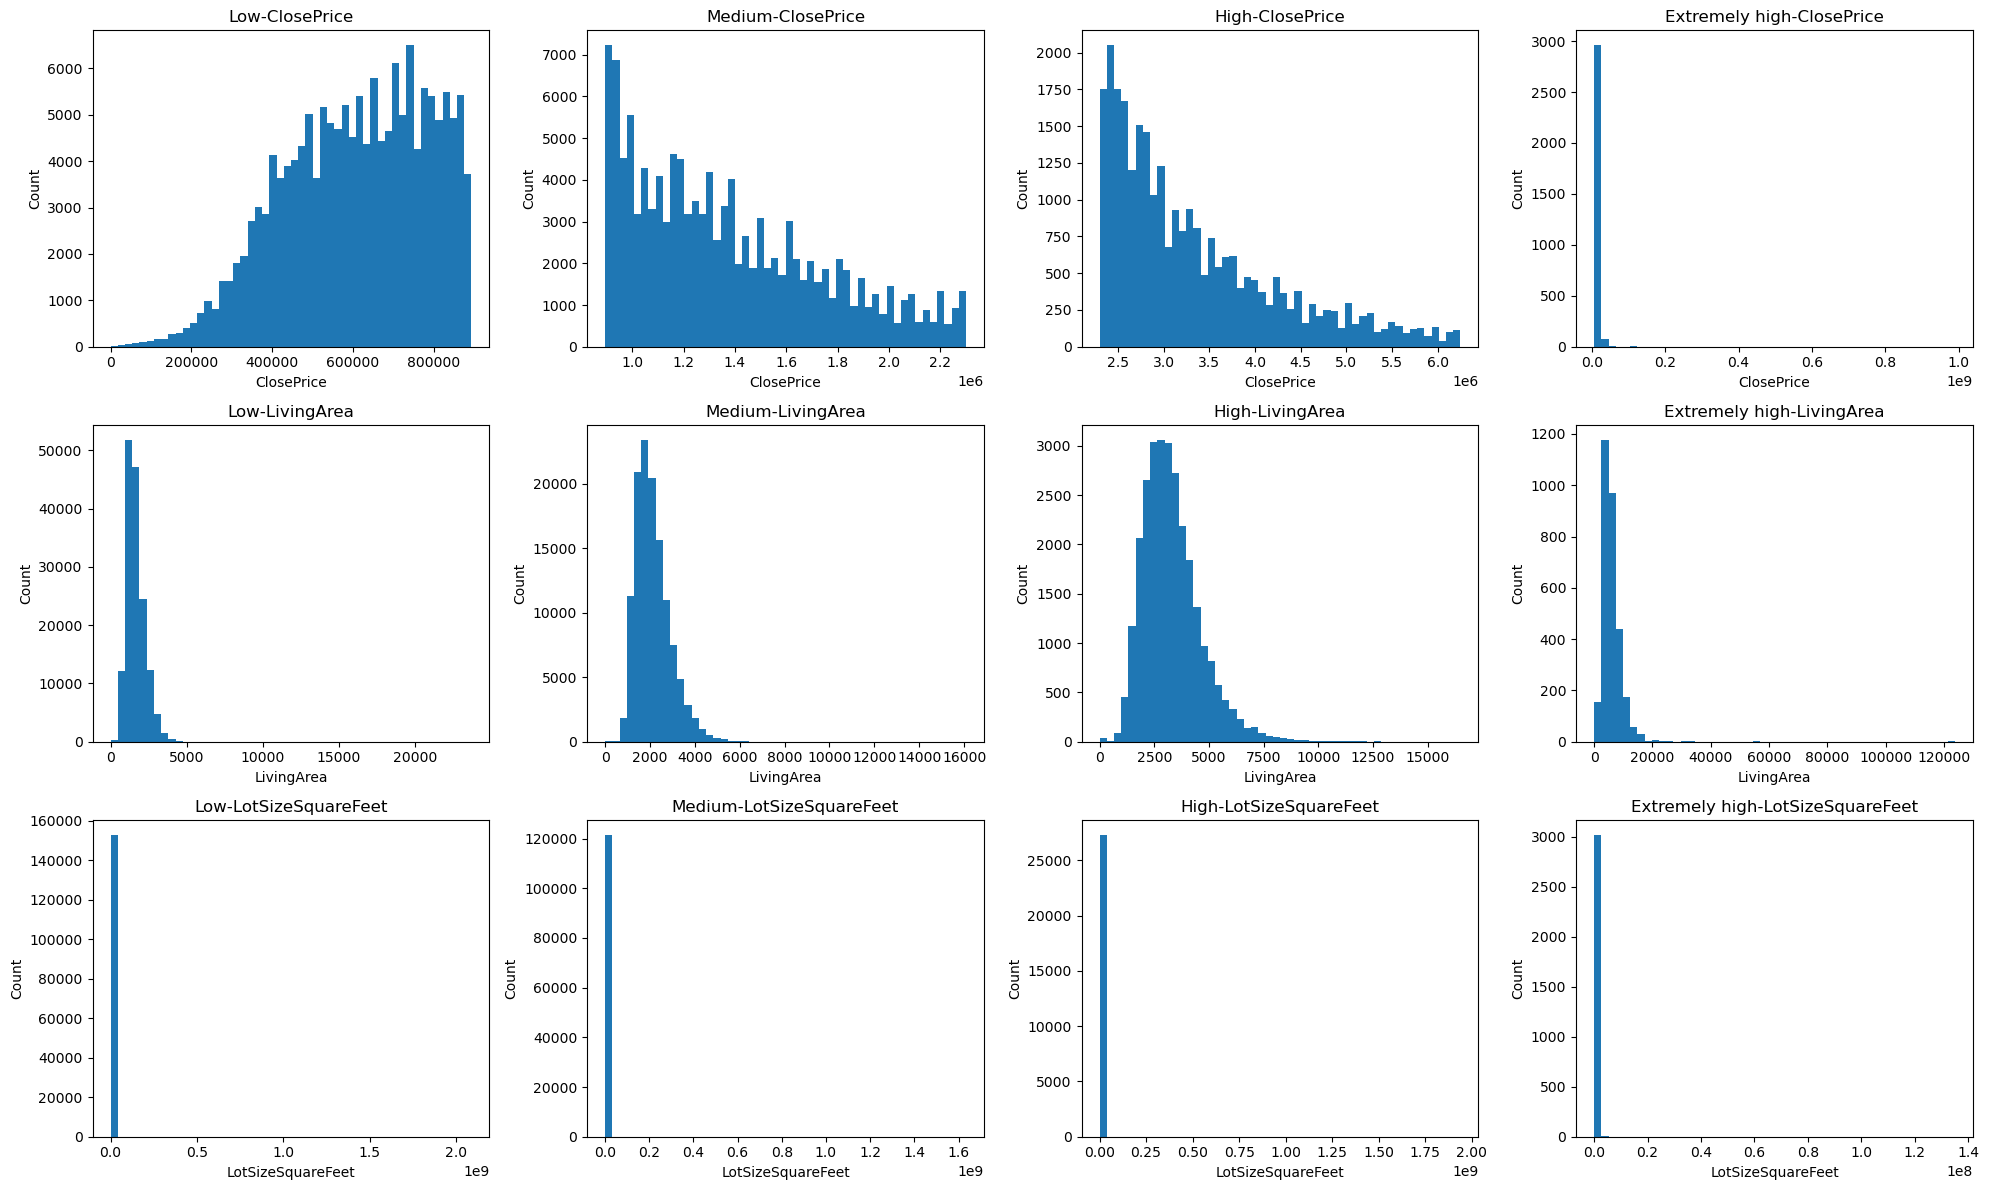

In [404]:
continuous_cols = ["ClosePrice", "LivingArea", "LotSizeSquareFeet"]

fig, axes = plt.subplots(len(continuous_cols), len(ClosePriceLabels), figsize=(20, 12), squeeze=False)

for i, col in enumerate(continuous_cols):
    for j, label in enumerate(ClosePriceLabels):
        ax = axes[i,j]
        values = pd.to_numeric(seg_data.loc[seg_data["close_price_segment"]==label, col])

        ax.hist(values, bins=50)
        ax.set_title(f"{label}-{col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [406]:
seg_data_summary = seg_data.groupby("close_price_segment", observed=False).agg(
    count = ("ClosePrice", "size"),
    min_close_price = ("ClosePrice", "min"),
    median_close_price = ("ClosePrice", "median"),
    max_close_price = ("ClosePrice", "max"),
    median_living_area=("LivingArea", "median"),
    median_bedrooms=("BedroomsTotal", "median"),
    median_bathrooms=("BathroomsTotalInteger", "median"),
    median_lot_size=("LotSizeSquareFeet", "median")
)

seg_data_summary["percentage"] = seg_data_summary["count"]/len(seg_data)
seg_data_summary.insert(1, "percentage", seg_data_summary.pop("percentage"))
seg_data_summary

,count,percentage,min_close_price,median_close_price,max_close_price,median_living_area,median_bedrooms,median_bathrooms,median_lot_size
close_price_segment,,,,,,,,,
Low,154889,0.500073,0.0,625000.0,894000.0,1541.0,3.0,2.0,7038.0
Medium,124018,0.400403,894200.0,1300000.0,2300000.0,1997.0,4.0,3.0,7202.0
High,27755,0.089609,2300004.0,3045000.0,6250000.0,3103.0,4.0,4.0,9450.0
Extremely high,3071,0.009915,6260000.0,8500000.0,989500000.0,5269.5,5.0,6.0,18851.0


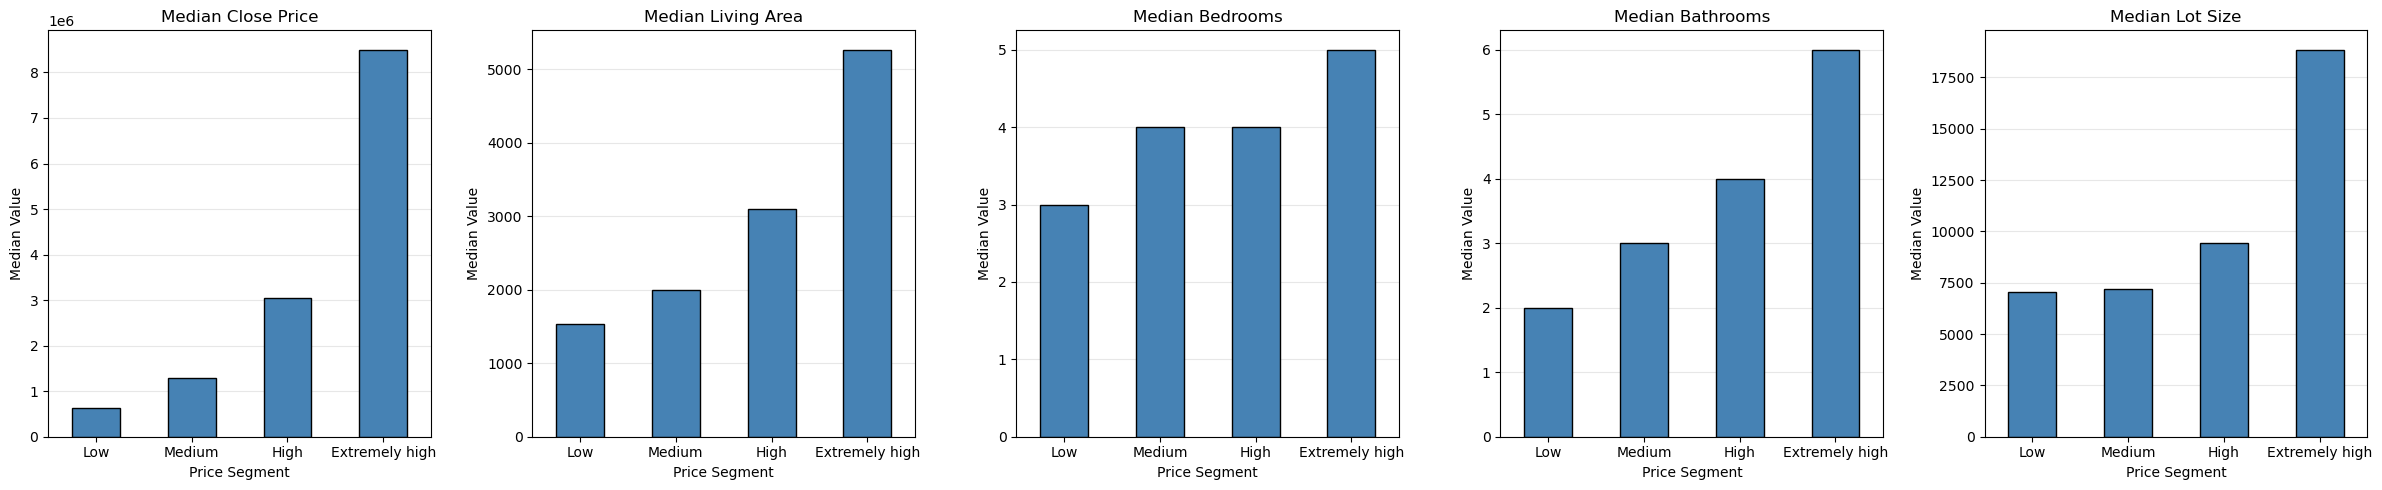

In [408]:
cols = ["median_close_price","median_living_area","median_bedrooms","median_bathrooms","median_lot_size"]

axes = seg_data_summary[cols].plot(kind="bar",subplots=True,layout=(1, 5),figsize=(24, 5),color="steelblue",edgecolor="black",legend=False,rot=0)

for ax, col in zip(axes.flat, cols):
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Price Segment")
    ax.set_ylabel("Median Value")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Patterns such as:
- Higher-priced homes have larger living areas or lots
- Higher-priced homes have more bathrooms

Next, we want to explore:
- Are extremely high-priced homes concentrated in particular cities?
- Are missing values more common in certain segments?

## Time series analysis of ClosePrice

In [294]:
ts_data = res_sfr_combined_sold_data[["CloseDate", "ClosePrice"]].copy()
ts_data

,CloseDate,ClosePrice
5,2024-01-05,815000.0
9,2024-01-05,810000.0
28,2024-01-02,2100000.0
29,2024-01-22,1950000.0
31,2024-01-31,2340000.0
...,...,...
615673,2026-04-30,525000.0
615674,2026-04-01,405000.0
615675,2026-04-01,215000.0
615677,2026-04-13,415000.0


In [296]:
ts_data["CloseDate"] = pd.to_datetime(ts_data["CloseDate"], errors="coerce")
ts_data["ClosePrice"] = pd.to_numeric(ts_data["ClosePrice"], errors="coerce")

# Exclude missing dates/prices and nonpositive prices from this analysis
ts_data = ts_data.dropna(subset=["CloseDate", "ClosePrice"])
ts_data = ts_data.loc[ts_data["ClosePrice"] > 0].copy()
ts_data = ts_data.sort_values("CloseDate")

print("Earliest close date:", ts_data["CloseDate"].min())
print("Latest close date:", ts_data["CloseDate"].max())

Earliest close date: 2024-01-01 00:00:00
Latest close date: 2026-04-30 00:00:00


In [298]:
monthly_summary = ts_data.resample("MS", on="CloseDate").agg(
    transaction_count=("ClosePrice", "size"),
    median_closeprice=("ClosePrice", "median"),
    mean_closeprice=("ClosePrice", "mean")
)

# Change compared with the previous calendar month
monthly_summary["monthly_change_pct"] = monthly_summary["median_closeprice"].pct_change(fill_method=None) * 100

# Smooth short-term fluctuations
monthly_summary["median_3month_avg"] = monthly_summary["median_closeprice"].rolling(window=3, min_periods=3).mean()

monthly_summary.round(2)

,transaction_count,median_closeprice,mean_closeprice,monthly_change_pct,median_3month_avg
CloseDate,,,,,
2024-01-01,8322,799000.0,1111002.41,NaN,NaN
2024-02-01,9564,860000.0,1192444.50,7.63,NaN
2024-03-01,11634,880000.0,1238435.32,2.33,846333.33
2024-04-01,12745,928000.0,1298763.08,5.45,889333.33
2024-05-01,13831,935000.0,1329968.94,0.75,914333.33
2024-06-01,12544,935000.0,1298233.11,0.00,932666.67
2024-07-01,13378,925000.0,1276134.50,-1.07,931666.67
2024-08-01,12433,900000.0,1283866.23,-2.70,920000.00
2024-09-01,10909,890000.0,1268398.07,-1.11,905000.00


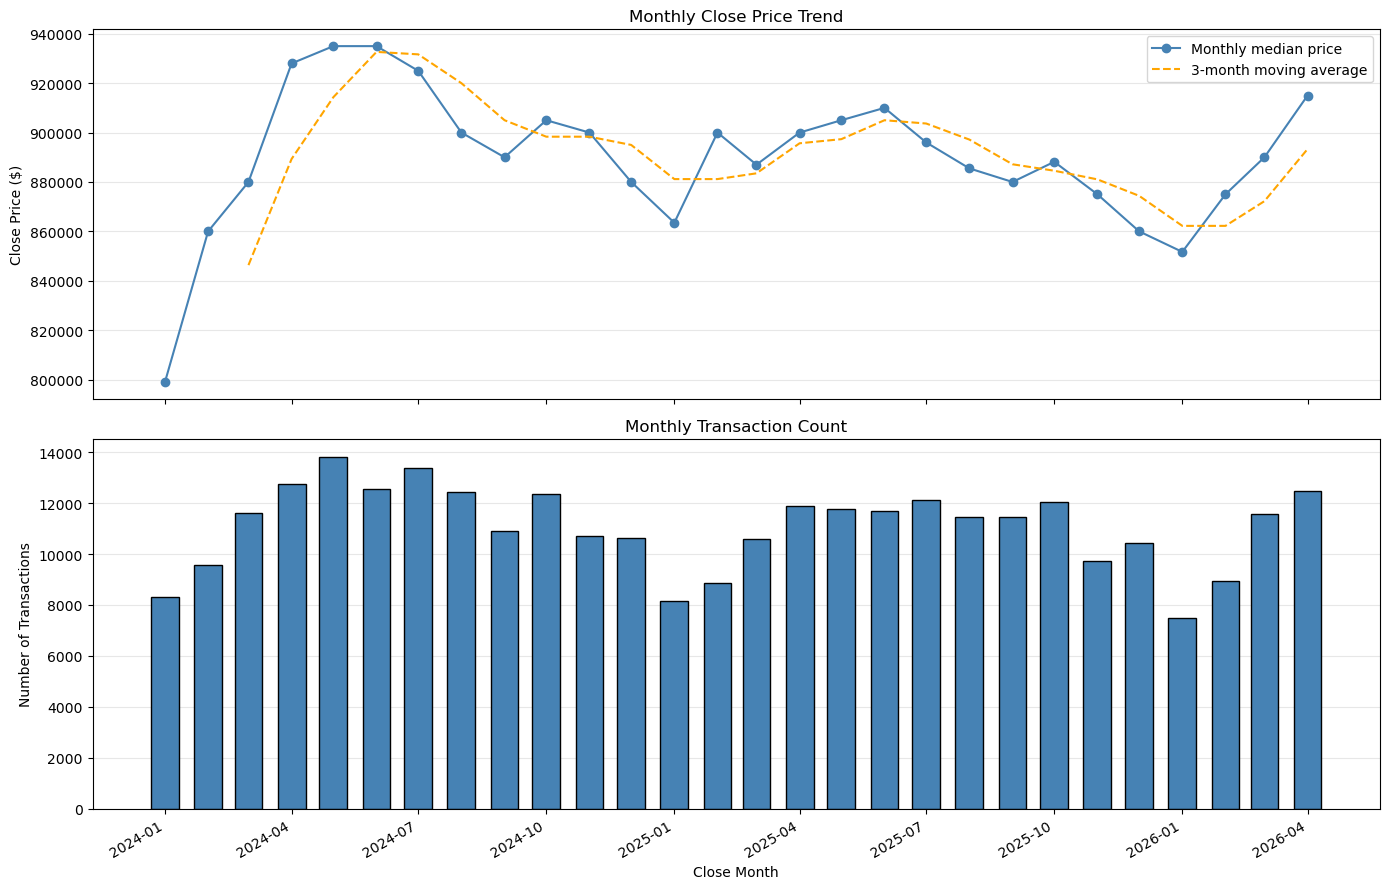

In [300]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Monthly price trend
axes[0].plot(monthly_summary.index,monthly_summary["median_closeprice"],marker="o",color="steelblue",label="Monthly median price")

axes[0].plot(monthly_summary.index,monthly_summary["median_3month_avg"],linestyle="--",color="orange",label="3-month moving average")

axes[0].set_title("Monthly Close Price Trend")
axes[0].set_ylabel("Close Price ($)")
axes[0].ticklabel_format(axis="y", style="plain")
axes[0].legend()

# Monthly transaction volume
axes[1].bar(monthly_summary.index,monthly_summary["transaction_count"],width=20,color="steelblue",edgecolor="black")

axes[1].set_title("Monthly Transaction Count")
axes[1].set_xlabel("Close Month")
axes[1].set_ylabel("Number of Transactions")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

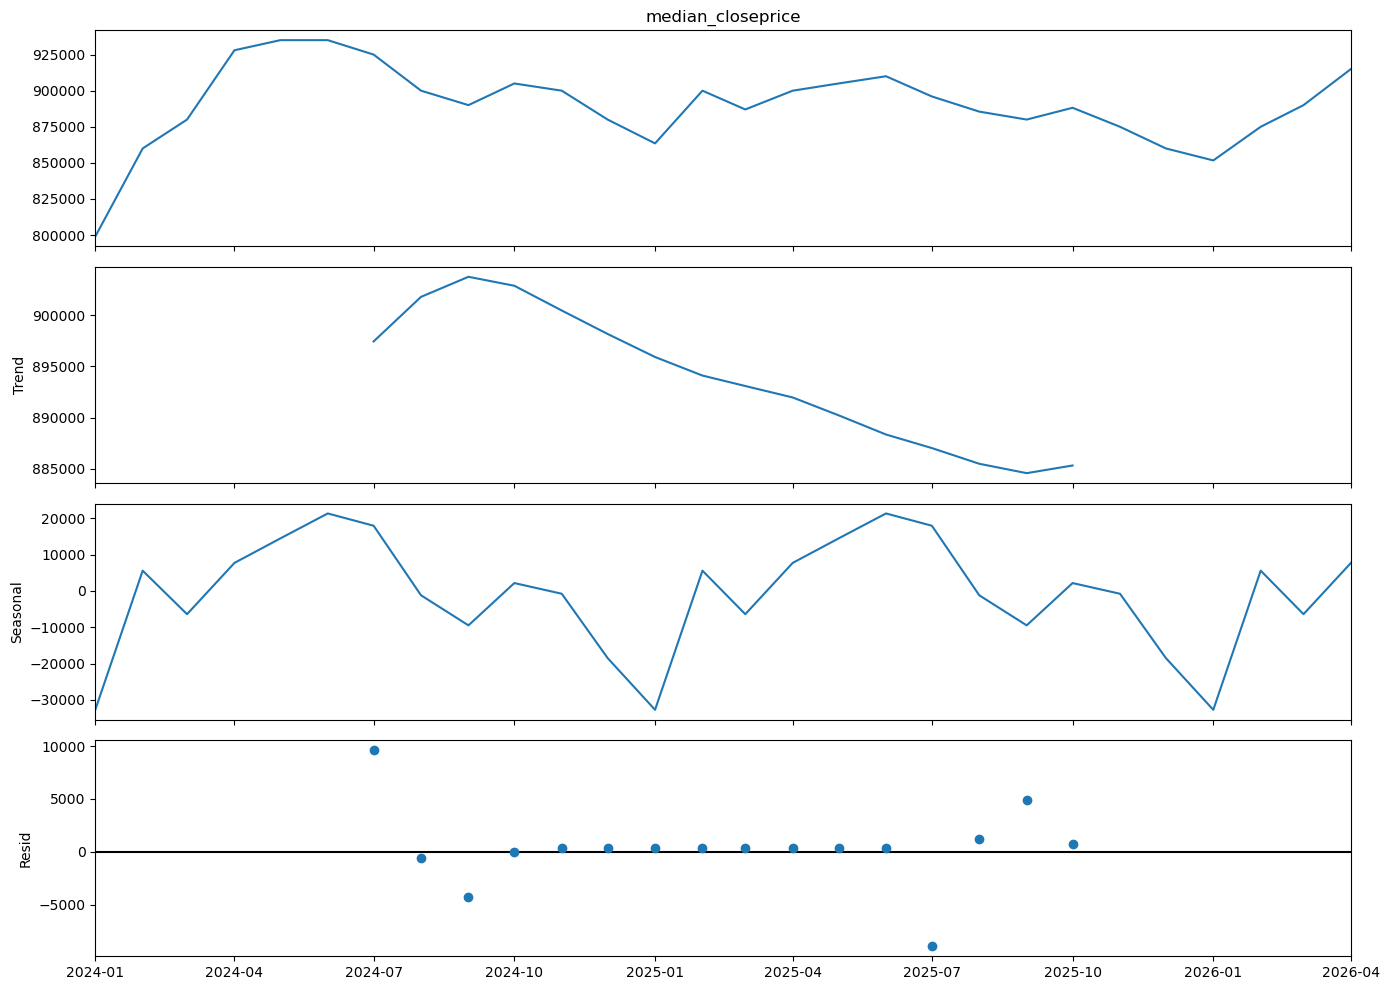

In [304]:
decomposition = seasonal_decompose(y, model="additive", period=12)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.tight_layout()
plt.show()